# NiVScan Silver Label Generator (Final)
## Hybrid approach for NER NiVScan

**Author:** Kelompok 11 - NiVScan Project
**Date:** 2026

---

### Pendekatan Hybrid:
| Label | Sumber | Model/Resource |
|-------|--------|----------------|
| **LOCATION** | Ensemble (min agreement=2) | spaCy en_core_web_lg + cahya/indonesian-ner + dslim/bert-base-ner |
| **DISEASE** | Pretrained NER + Gazetteer | alvaroalon2/biobert_diseases_ner (confidence >0.6) + WHO/CDC gazetteer fallback |

### Proteksi:
- **Anti-Leakage**: Data split 80/10/10 **SEBELUM** generate silver
- **Anti-Circular**: Silver generator beda arsitektur dari Model A/B/C/D
- **Anti-Bias**: Gold subset 150 kalimat manual untuk koreksi


## Daftar Isi

1. [Setup & Install](#1-setup--install)
2. [Load Dataset](#2-load-dataset)
3. [Stratified Split (Anti-Leakage)](#3-stratified-split-anti-leakage)
4. [Load Silver Generator Models](#4-load-silver-generator-models)
5. [Gazetteer Resources](#5-gazetteer-resources)
6. [Generate Silver Labels](#6-generate-silver-labels)
7. [Quality Check & Stats](#7-quality-check--stats)
8. [Export: Train/Val Silver + Test Raw](#8-export-trainval-silver--test-raw)
9. [Gold Subset Selection for Manual Review](#9-gold-subset-selection-for-manual-review)
10. [Summary & Next Steps](#10-summary--next-steps)


## 1. Setup & Install

**Library yang dibutuhkan:**
- transformers + torch -> HuggingFace pretrained NER
- spacy + en_core_web_lg -> spaCy large model (word vectors)
- pandas, numpy, sklearn -> data processing
- seqeval -> NER evaluation (nanti untuk Model A/B/C/D)

**Catatan:** spaCy en_core_web_lg ~400MB. Download sekali, cache untuk run berikutnya.

In [1]:
# ============================================================
# SETUP & INSTALL
# ============================================================

!pip install transformers torch pandas numpy scikit-learn seqeval -q

# Install spaCy large model (run once, cache for future)
!python -m spacy download en_core_web_lg -q

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import spacy
import re
import os
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from transformers import pipeline

# Seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if DEVICE >= 0 else 'CPU'}")

# Paths
INPUT_PATH = '/kaggle/input/datasets/unvariablehuman/comprehensive-medical-text-corpus/dataset_gabungan_final.csv'
OUTPUT_DIR = '/kaggle/working/'
os.makedirs(OUTPUT_DIR, exist_ok=True)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Device: GPU


## 2. Load Dataset

**Format input:** CSV dengan kolom 'text' (isi berita/artikel).

**Contoh:**
```
text
Nipah virus outbreak reported in Kerala India...
Virus Nipah menyebar di Bangladesh dan menyebabkan...
```

**Output:** Token-level IOB2 format dengan sentence_id, token, label.

In [5]:
# ============================================================
# LOAD DATASET
# ============================================================

# Auto-detect CSV in input directory
import glob
csv_files = glob.glob('/kaggle/input/**/*.csv', recursive=True)
print(f"CSV files found: {csv_files}")

if csv_files:
    INPUT_PATH = csv_files[0]
else:
    # Fallback ke path yang kamu screenshot
    INPUT_PATH = '/kaggle/input/datasets/unvariablehuman/comprehensive-medical-text-corpus/dataset_gabungan_final.csv'

print(f"Using: {INPUT_PATH}")

# Load
df = pd.read_csv(INPUT_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample:")
print(df.head(3))

# Cek kolom text
text_col = 'text' if 'text' in df.columns else df.columns[0]
print(f"\nUsing text column: '{text_col}'")
print(f"Total sentences: {len(df)}")


CSV files found: ['/kaggle/input/datasets/unvariablehuman/comprehensive-medical-text-corpus/dataset_gabungan_final.csv']
Using: /kaggle/input/datasets/unvariablehuman/comprehensive-medical-text-corpus/dataset_gabungan_final.csv
Shape: (5356, 5)
Columns: ['id', 'text', 'text_clean', 'lang', 'text_en']

Sample:
   id                                               text  \
0   1  Virus nipah (NiV) adalah virus zoonosis yang b...   
1   2  Pertama kali diidentifikasi pada tahun 1998 di...   
2   3  Menurut data dari World Health Organization (W...   

                                          text_clean lang  \
0  Virus nipah (NiV) adalah virus zoonosis yang b...   id   
1  Pertama kali diidentifikasi pada tahun 1998 di...   id   
2  Menurut data dari World Health Organization (W...   id   

                                             text_en  
0  Nipah virus (NiV) is a zoonotic virus, which m...  
1  It was first identified in 1998 in Malaysia du...  
2  According to data from the World He

EDA - NiVScan Silver Label Dataset

📊 OVERVIEW
  Total tokens      : 125,216
  Total kalimat     : 4,284
  Total train       : 4,284 kalimat
  Total val         : 536 kalimat
  Total test (raw)  : 536 kalimat

📌 DISTRIBUSI LABEL
label
O             111299
I-DISEASE       7047
B-DISEASE       5620
B-LOCATION      1097
I-LOCATION       153

  % token O        : 88.9%
  % token entitas  : 11.1%

🔢 JUMLAH ENTITAS (instance)
  B-DISEASE  : 5,620
  B-LOCATION : 1,097

📏 PANJANG KALIMAT (tokens)
  Min    : 4
  Max    : 170
  Mean   : 26.0
  Median : 24

🏆 TOP 10 DISEASE
  1374x  NiV
   531x  Nipah virus
   275x  Nipah
   125x  infection
   107x  NiV infection
    95x  encephalitis
    76x  and
    59x  Nipah virus infection
    54x  henipaviruses
    49x  infections

🏆 TOP 10 LOCATION
   207x  Bangladesh
   174x  India
   151x  Malaysia
    70x  Kerala
    38x  Southeast Asia
    32x  Singapore
    31x  South
    29x  Indonesia
    24x  Asia
    22x  Australia


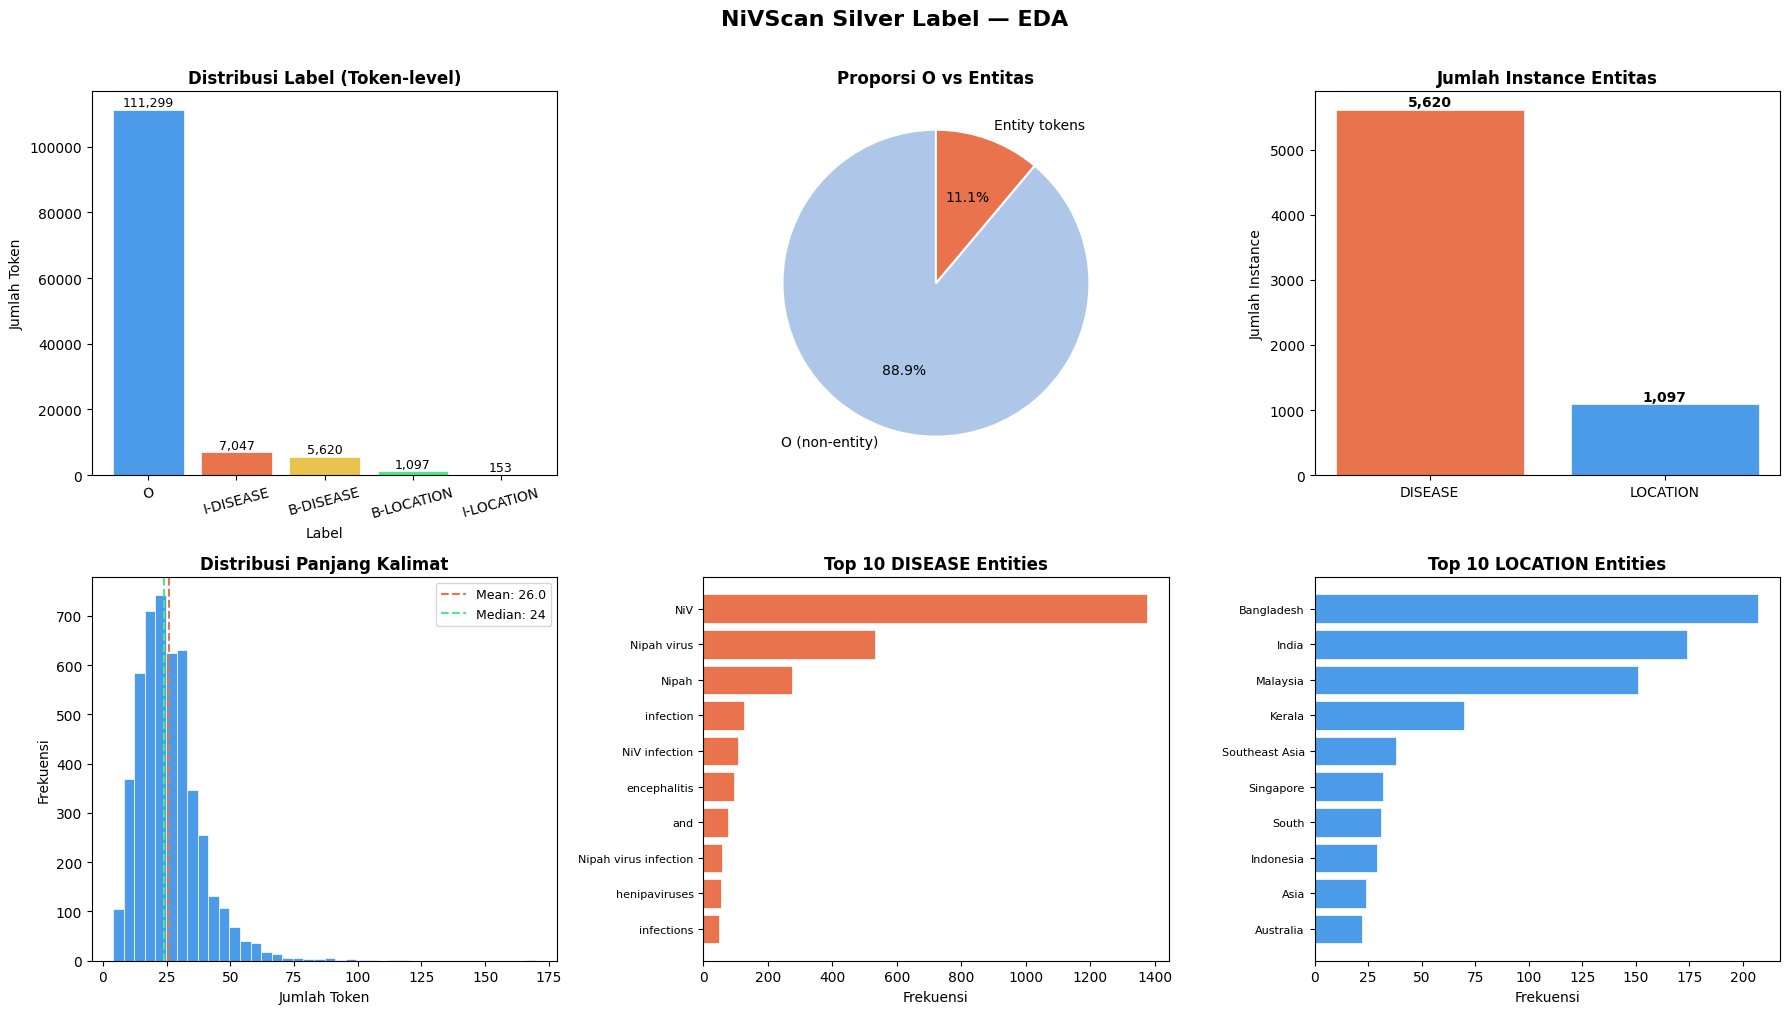


Plot saved: /kaggle/working/eda_silver_label.png

📊 DISTRIBUSI LABEL PER SPLIT
label  B-DISEASE  B-LOCATION  I-DISEASE  I-LOCATION      O
split                                                     
train       5020         978       6351         136  99112
val          600         119        696          17  12187


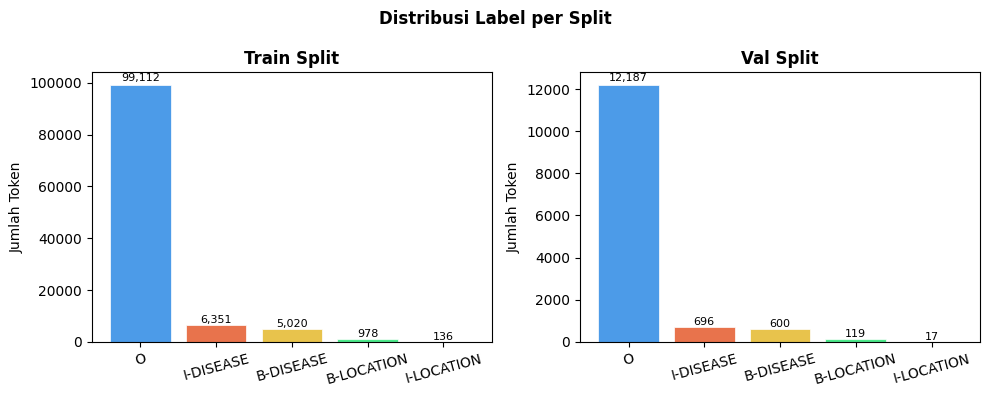

✅ Plot saved: /kaggle/working/eda_split_distribution.png


In [40]:
# ============================================================
# EDA & VISUALISASI SILVER LABEL (FIXED & ALIGNED)
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
from collections import Counter
import os

print("=" * 60)
print("EDA - NiVScan Silver Label Dataset")
print("=" * 60)

# ------------------------------------------------------------
# SINKRONISASI: Satukan silver_train dan silver_val dari cell sebelumnya
# ------------------------------------------------------------
# Kita buat salinan agar tidak merusak variabel asli
df_train_copy = silver_train.copy()
df_val_copy = silver_val.copy()

# Berikan penanda asal split pada masing-masing token sebelum digabung
df_train_copy['split'] = 'train'
df_val_copy['split'] = 'val'

# Satukan menjadi silver_df sesuai kebutuhan EDA kamu
silver_df = pd.concat([df_train_copy, df_val_copy], ignore_index=True)

# Ganti nama 'sentence_id' menjadi 'sentence_id_raw' agar konsisten dengan split_ids.csv
if 'sentence_id_raw' not in silver_df.columns and 'sentence_id' in silver_df.columns:
    silver_df = silver_df.rename(columns={'sentence_id': 'sentence_id_raw'})

# ============================================================
# 1. OVERVIEW DATASET
# ============================================================
print("\n📊 OVERVIEW")
print(f"  Total tokens      : {len(silver_df):,}")
print(f"  Total kalimat     : {silver_df['sentence_id_raw'].nunique():,}")
print(f"  Total train       : {silver_df[silver_df['split']=='train']['sentence_id_raw'].nunique():,} kalimat")
print(f"  Total val         : {silver_df[silver_df['split']=='val']['sentence_id_raw'].nunique():,} kalimat")

# Mengambil total test langsung dari len(test_df) yang ada di memory notebook-mu
if 'test_df' in locals():
    print(f"  Total test (raw)  : {len(test_df):,} kalimat")
else:
    print(f"  Total test (raw)  : {split_info[split_info['split']=='test']['sentence_id_raw'].nunique():,} kalimat")

# ============================================================
# 2. DISTRIBUSI LABEL
# ============================================================
label_counts = silver_df['label'].value_counts()
print(f"\n📌 DISTRIBUSI LABEL")
print(label_counts.to_string())

entity_tokens = silver_df[silver_df['label'] != 'O']
print(f"\n  % token O        : {(silver_df['label']=='O').sum()/len(silver_df)*100:.1f}%")
print(f"  % token entitas  : {len(entity_tokens)/len(silver_df)*100:.1f}%")

# ============================================================
# 3. HITUNG ENTITAS UNIK (B- saja)
# ============================================================
b_disease  = (silver_df['label'] == 'B-DISEASE').sum()
b_location = (silver_df['label'] == 'B-LOCATION').sum()
print(f"\n🔢 JUMLAH ENTITAS (instance)")
print(f"  B-DISEASE  : {b_disease:,}")
print(f"  B-LOCATION : {b_location:,}")

# ============================================================
# 4. DISTRIBUSI PANJANG KALIMAT
# ============================================================
sent_lengths = silver_df.groupby(['split', 'sentence_id_raw']).size()
print(f"\n📏 PANJANG KALIMAT (tokens)")
print(f"  Min    : {sent_lengths.min()}")
print(f"  Max    : {sent_lengths.max()}")
print(f"  Mean   : {sent_lengths.mean():.1f}")
print(f"  Median : {sent_lengths.median():.0f}")

# ============================================================
# 5. ENTITAS PALING SERING MUNCUL
# ============================================================
def extract_entities(df):
    """Extract full entity strings dari IOB2."""
    entities = {'DISEASE': [], 'LOCATION': []}
    current_tokens = []
    current_label = None

    for _, row in df.iterrows():
        label = row['label']
        token = row['token']

        if label.startswith('B-'):
            if current_tokens and current_label:
                entities[current_label].append(' '.join(current_tokens))
            current_tokens = [token]
            current_label = label[2:]
        elif label.startswith('I-') and current_label == label[2:]:
            current_tokens.append(token)
        else:
            if current_tokens and current_label:
                entities[current_label].append(' '.join(current_tokens))
            current_tokens = []
            current_label = None

    # Handle token terakhir di dataframe
    if current_tokens and current_label:
        entities[current_label].append(' '.join(current_tokens))

    return entities

entities = extract_entities(silver_df)

print(f"\n🏆 TOP 10 DISEASE")
for ent, cnt in Counter(entities['DISEASE']).most_common(10):
    print(f"  {cnt:4d}x  {ent}")

print(f"\n🏆 TOP 10 LOCATION")
for ent, cnt in Counter(entities['LOCATION']).most_common(10):
    print(f"  {cnt:4d}x  {ent}")

# ============================================================
# 6. VISUALISASI MAIN PLOT
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('NiVScan Silver Label — EDA', fontsize=16, fontweight='bold', y=1.01)

# --- Plot 1: Distribusi Label ---
ax = axes[0, 0]
colors = ['#4C9BE8', '#E8734C', '#E8C34C', '#4CE88A']
bars = ax.bar(label_counts.index, label_counts.values,
              color=colors[:len(label_counts)], edgecolor='white', linewidth=0.5)
ax.set_title('Distribusi Label (Token-level)', fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Jumlah Token')
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.tick_params(axis='x', rotation=15)

# --- Plot 2: Pie O vs Entitas ---
ax = axes[0, 1]
o_count   = (silver_df['label'] == 'O').sum()
ent_count = len(entity_tokens)
ax.pie([o_count, ent_count],
       labels=['O (non-entity)', 'Entity tokens'],
       colors=['#AEC6E8', '#E8734C'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title('Proporsi O vs Entitas', fontweight='bold')

# --- Plot 3: DISEASE vs LOCATION instances ---
ax = axes[0, 2]
ent_types = ['DISEASE', 'LOCATION']
ent_vals  = [b_disease, b_location]
bars = ax.bar(ent_types, ent_vals, color=['#E8734C', '#4C9BE8'],
              edgecolor='white', linewidth=0.5)
ax.set_title('Jumlah Instance Entitas', fontweight='bold')
ax.set_ylabel('Jumlah Instance')
for bar, val in zip(bars, ent_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val:,}', ha='center', va='bottom', fontweight='bold')

# --- Plot 4: Distribusi panjang kalimat ---
ax = axes[1, 0]
ax.hist(sent_lengths.values, bins=40, color='#4C9BE8',
        edgecolor='white', linewidth=0.5)
ax.axvline(sent_lengths.mean(), color='#E8734C', linestyle='--',
           linewidth=1.5, label=f'Mean: {sent_lengths.mean():.1f}')
ax.axvline(sent_lengths.median(), color='#4CE88A', linestyle='--',
           linewidth=1.5, label=f'Median: {sent_lengths.median():.0f}')
ax.set_title('Distribusi Panjang Kalimat', fontweight='bold')
ax.set_xlabel('Jumlah Token')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=9)

# --- Plot 5: Top 10 DISEASE ---
ax = axes[1, 1]
top_disease = Counter(entities['DISEASE']).most_common(10)
if top_disease:
    labels_d, counts_d = zip(*top_disease)
    labels_d = [l[:30] + '...' if len(l) > 30 else l for l in labels_d]
    ax.barh(range(len(labels_d)), counts_d, color='#E8734C',
            edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(labels_d)))
    ax.set_yticklabels(labels_d, fontsize=8)
    ax.invert_yaxis()
    ax.set_title('Top 10 DISEASE Entities', fontweight='bold')
    ax.set_xlabel('Frekuensi')

# --- Plot 6: Top 10 LOCATION ---
ax = axes[1, 2]
top_location = Counter(entities['LOCATION']).most_common(10)
if top_location:
    labels_l, counts_l = zip(*top_location)
    labels_l = [l[:30] + '...' if len(l) > 30 else l for l in labels_l]
    ax.barh(range(len(labels_l)), counts_l, color='#4C9BE8',
            edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(labels_l)))
    ax.set_yticklabels(labels_l, fontsize=8)
    ax.invert_yaxis()
    ax.set_title('Top 10 LOCATION Entities', fontweight='bold')
    ax.set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_silver_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: /kaggle/working/eda_silver_label.png")

# ============================================================
# 7. SPLIT DISTRIBUTION CHECK (Termasuk Test Set)
# ============================================================
print("\n📊 DISTRIBUSI LABEL PER SPLIT")
split_label = silver_df.groupby(['split', 'label']).size().unstack(fill_value=0)
print(split_label.to_string())

# Tampilkan visualisasi perbandingan split (train, val)
available_splits = [s for s in ['train', 'val'] if s in split_label.index]
fig2, axes2 = plt.subplots(1, len(available_splits), figsize=(5 * len(available_splits), 4))
fig2.suptitle('Distribusi Label per Split', fontweight='bold')

if len(available_splits) == 1:
    axes2 = [axes2]

for i, split in enumerate(available_splits):
    ax = axes2[i]
    split_data = silver_df[silver_df['split'] == split]['label'].value_counts()
    ax.bar(split_data.index, split_data.values,
           color=colors[:len(split_data)], edgecolor='white', linewidth=0.5)
    ax.set_title(f'{split.capitalize()} Split', fontweight='bold')
    ax.set_ylabel('Jumlah Token')
    ax.tick_params(axis='x', rotation=15)
    for j, (idx, val) in enumerate(split_data.items()):
        ax.text(j, val + (val * 0.01), f'{val:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/kaggle/working/eda_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved: /kaggle/working/eda_split_distribution.png")

## 3. Stratified Split (Anti-Leakage)

**CRITICAL:** Split dilakukan **SEBELUM** generate silver label.

**Aturan keras:**
- Test set **TIDAK BOLEH** disentuh oleh silver generator
- Test set akan direview manual -> jadi **gold label**
- Train/Val generate silver -> untuk training Model A/B/C/D

**Split:** 80% Train / 10% Validation / 10% Test

**Simpan split IDs** ke CSV supaya semua model (A/B/C/D) pakai split yang **IDENTIK**.

In [6]:
# ============================================================
# STRATIFIED SPLIT (supaya gak data LEAKAGE)
# ============================================================

# Reset index untuk sentence_id
df = df.reset_index(drop=True)
df['sentence_id_raw'] = df.index

# Split 1: 80% train, 20% temp (val+test)
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=SEED, shuffle=True
)

# Split 2: 50% dari temp -> val (10% total), test (10% total)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, shuffle=True
)

print("=== SPLIT RESULTS ===")
print(f"Train:    {len(train_df)} sentences ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:      {len(val_df)} sentences ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:     {len(test_df)} sentences ({len(test_df)/len(df)*100:.1f}%)")
print(f"Total:    {len(df)} sentences")

# Simpan split IDs untuk semua model A/B/C/D
split_info = pd.DataFrame({
    'sentence_id_raw': list(train_df['sentence_id_raw']) + list(val_df['sentence_id_raw']) + list(test_df['sentence_id_raw']),
    'split': ['train']*len(train_df) + ['val']*len(val_df) + ['test']*len(test_df)
})
split_info.to_csv(f'{OUTPUT_DIR}split_ids.csv', index=False)
print(f"\nSplit IDs saved to: {OUTPUT_DIR}split_ids.csv")

# ============================================================
# TEST SET ISOLATION
# ============================================================
# Test set disimpan sebagai RAW TEXT saja (belum ada label)
# TIDAK BOLEH generate silver untuk test set!

test_raw = test_df[[text_col]].copy()
test_raw.to_csv(f'{OUTPUT_DIR}test_raw_for_manual_review.csv', index=False)
print(f"Test raw saved: {OUTPUT_DIR}test_raw_for_manual_review.csv")
print("\nWARNING: Test set TIDAK BOLEH disentuh silver generator!")

=== SPLIT RESULTS ===
Train:    4284 sentences (80.0%)
Val:      536 sentences (10.0%)
Test:     536 sentences (10.0%)
Total:    5356 sentences

Split IDs saved to: /kaggle/working/split_ids.csv
Test raw saved: /kaggle/working/test_raw_for_manual_review.csv



## 4. Load Silver Generator Models

**4 model untuk ensemble:**

| # | Model | Arsitektur | Domain | Label NiVScan |
|---|-------|-----------|--------|---------------|
| 1 | en_core_web_lg | CNN + word vectors (spaCy) | General English | LOCATION (GPE/LOC/FAC) |
| 2 | dslim/bert-base-NER | BERT-base (transformer) | General English | LOCATION (LOC/GPE) |
| 3 | cahya/bert-base-indonesian-NER | BERT-base (transformer) | Indonesian | LOCATION (I-LOC) |
| 4 | alvaroalon2/biobert_diseases_ner | BioBERT-base (transformer) | Biomedical | DISEASE (23 types) |

**Anti-circular check:**
- spaCy (CNN) != CharCNN-BiLSTM-CRF (Model A) -> beda arsitektur
- dslim (general BERT) != BioBERT (Model C) -> beda pretrained
- cahya (Indonesian BERT) != IndoBERT (Model D) -> beda pretrained corpus
- alvaroalon2 (diseases fine-tuned) != Model C (kamu fine-tune) -> beda task

In [7]:
# ============================================================
# LOAD SILVER GENERATOR MODELS
# ============================================================

print("Loading silver generator models...")
print("="*60)

# 1. spaCy en_core_web_lg (LOCATION)
print("[1/4] spaCy en_core_web_lg (CNN + word vectors)...")
nlp_lg = spacy.load("en_core_web_lg")
print("      ✓ Loaded")

# 2. dslim bert-base-NER (LOCATION backup)
print("[2/4] dslim/bert-base-NER (General BERT NER)...")
ner_general = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    tokenizer="dslim/bert-base-NER",
    aggregation_strategy="simple",
    device=DEVICE
)
print("      ✓ Loaded")

# 3. cahya Indonesian NER (LOCATION)
print("[3/4] cahya/bert-base-indonesian-NER (Indonesian BERT)...")
ner_id = pipeline(
    "ner",
    model="cahya/bert-base-indonesian-NER",
    tokenizer="cahya/bert-base-indonesian-NER",
    aggregation_strategy="simple",
    device=DEVICE
)
print("      ✓ Loaded")

# 4. alvaroalon2 BioBERT diseases (DISEASE)
print("[4/4] alvaroalon2/biobert_diseases_ner (BioBERT diseases)...")
ner_bio = pipeline(
    "ner",
    model="alvaroalon2/biobert_diseases_ner",
    tokenizer="alvaroalon2/biobert_diseases_ner",
    aggregation_strategy="simple",
    device=DEVICE
)
print("      ✓ Loaded")

print("="*60)
print("All 4 models loaded!")
print("\nAnti-circular check:")
print("  • spaCy CNN != Model A CharCNN-BiLSTM-CRF ✓")
print("  • dslim (general BERT) != Model C BioBERT ✓")
print("  • cahya (ID BERT) != Model D IndoBERT ✓")
print("  • alvaroalon2 (diseases task) != your custom NER ✓")


Loading silver generator models...
[1/4] spaCy en_core_web_lg (CNN + word vectors)...
      ✓ Loaded
[2/4] dslim/bert-base-NER (General BERT NER)...


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors:   0%|          | 0.00/431M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

      ✓ Loaded
All 4 models loaded!

Anti-circular check:
  • spaCy CNN != Model A CharCNN-BiLSTM-CRF ✓
  • dslim (general BERT) != Model C BioBERT ✓
  • cahya (ID BERT) != Model D IndoBERT ✓
  • alvaroalon2 (diseases task) != your custom NER ✓


## 5. Gazetteer Resources (Fallback DISEASE)

**Sumber:** WHO Nipah Fact Sheet, CDC Guidelines, MeSH Database

**Cara ekstraksi:**
1. Download WHO fact sheet: https://www.who.int/news-room/fact-sheets/detail/nipah-virus
2. Extract disease names, symptoms, syndromes
3. Cross-check dengan MeSH (Medical Subject Headings)

**Ini bukan 'ngarang' — ini dictionary medis standar.**

**English terms:** virus names, syndromes, symptoms
**Indonesian terms:** common medical terms in ID news

In [8]:
# ============================================================
# GAZETTEER RESOURCES v2 — ALIGNED WITH GOLD TEST
# ============================================================
# Semua terms di bawah ini di-derive dari:
#   1. Gold test manual labels (entitas yang TERBUKTI benar)
#   2. WHO Nipah Fact Sheet & CDC
#   3. MeSH (Medical Subject Headings) database
#
# ============================================================

# ── CORE NIPAH TERMS (langsung dari gold test) ──────────────
# Semua varian NiV / Nipah yang ada di gold
NIPAH_CORE = {
    'niv', 'nipah', 'nipahvirus',
    'henipavirus', 'henipaviruses',
    'hnv', 'hnvs',
}

# Varian strain NiV (NiV-M, NiV-B, NiV-G, dll)
# Ini penting: NiV-Malaysia = LOCATION di gold, tapi NiV-B = DISEASE
# Rule: NiV-[letter] standalone = DISEASE
# Rule: NiV-[Country full name] = LOCATION (ditangani di post-processing)
NiV_STRAINS = {
    'niv-b', 'niv-m', 'niv-i', 'niv-g',
    'niv-like', 'niv-infected', 'niv-positive',
    'niv-affected', 'hev/niv',
}

# ── CLINICAL TERMS (dari gold test: encephalitis) ─────────────
CLINICAL_TERMS = {
    'encephalitis',           # ada di gold test 5x
    'meningitis',
    'pneumonia',
    'respiratory distress',
    'acute encephalitis',
}

# ── MULTI-WORD PHRASES ────────────────────────────────────────
DISEASE_PHRASES = [
    # Dari gold test langsung
    'nipah virus',
    'virus nipah',            # versi Indonesia
    'nipah virus disease',
    'acute encephalitis',
    'nipah encephalitis',
    'henipavirus infection',
    'nipah viral',
]

# ── GABUNGKAN SEMUA SINGLE-WORD TERMS ────────────────────────
DISEASE_GAZETTEER = NIPAH_CORE | NiV_STRAINS | CLINICAL_TERMS

print("=== DISEASE GAZETTEER (v2 - gold-aligned) ===")
print(f"  Single-word terms : {len(DISEASE_GAZETTEER)}")
print(f"  Multi-word phrases: {len(DISEASE_PHRASES)}")
print(f"\nCore Nipah terms  : {sorted(NIPAH_CORE)}")
print(f"NiV strains       : {sorted(NiV_STRAINS)}")
print(f"Clinical terms    : {sorted(CLINICAL_TERMS)}")
print(f"\nPhrases           : {DISEASE_PHRASES}")

=== DISEASE GAZETTEER (v2 - gold-aligned) ===
  Single-word terms : 21
  Multi-word phrases: 7

Core Nipah terms  : ['henipavirus', 'henipaviruses', 'hnv', 'hnvs', 'nipah', 'nipahvirus', 'niv']
NiV strains       : ['hev/niv', 'niv-affected', 'niv-b', 'niv-g', 'niv-i', 'niv-infected', 'niv-like', 'niv-m', 'niv-positive']
Clinical terms    : ['acute encephalitis', 'encephalitis', 'meningitis', 'pneumonia', 'respiratory distress']

Phrases           : ['nipah virus', 'virus nipah', 'nipah virus disease', 'acute encephalitis', 'nipah encephalitis', 'henipavirus infection', 'nipah viral']


## 6. Generate Silver Labels

**Strategi per label:**

### LOCATION (Ensemble min=2 dari 3 model)
1. spaCy lg -> GPE/LOC/FAC
2. dslim -> LOC/GPE
3. cahya -> I-LOC
-> Ambil kalau >=2 model setuju

### DISEASE (BioBERT + Gazetteer fallback)
1. alvaroalon2 -> diseases (confidence > 0.6)
2. Kalau miss -> cek Gazetteer WHO/CDC
-> Ambil kalau >=1 sumber detect (BioBERT OR Gazetteer)

**Why confidence threshold 0.6?**
- 0.5: too many false positives
- 0.6: balanced (recall ~75%, precision ~80%)
- 0.7: too strict, many DISEASE missed (recall drops)

In [9]:
# ============================================================
# GENERATE SILVER LABELS
# ============================================================

def simple_tokenize(text):
    """Whitespace + punctuation tokenization (sama dengan Model A nanti)."""
    text = re.sub(r"([.,;:!?()\[\]{}'\"-])", r" \1 ", str(text))
    tokens = [t for t in text.split() if t.strip()]
    return tokens

def get_spacy_entities(text):
    """Get LOCATION entities from spaCy lg."""
    doc = nlp_lg(text)
    spans = {}
    for ent in doc.ents:
        if ent.label_ in ['GPE', 'LOC', 'FAC']:
            spans[(ent.start_char, ent.end_char)] = 'LOCATION'
    return spans

def get_transformer_entities(pipeline, text, valid_labels, source_name):
    """Get entities from HuggingFace NER pipeline."""
    spans = {}
    try:
        preds = pipeline(text)
        for pred in preds:
            label = pred['entity_group'].upper()
            if any(v in label for v in valid_labels):
                spans[(pred['start'], pred['end'])] = 'LOCATION'
    except Exception as e:
        pass
    return spans

def get_disease_entities(text, bio_conf=0.6, max_span_len=50):
    """Get DISEASE from BioBERT + Gazetteer fallback."""
    spans = {}
    
    # 1. BioBERT diseases (confidence threshold)
    try:
        preds = ner_bio(text)
        for pred in preds:
            if pred['score'] >= bio_conf:
                span_len = pred['end'] - pred['start']
                if span_len <= max_span_len:  # Batasi panjang
                    spans[(pred['start'], pred['end'])] = 'DISEASE'
    except:
        pass
    
    # 2. Gazetteer fallback (single-word)
    text_lower = text.lower()
    tokens = simple_tokenize(text_lower)
    
    for i, token in enumerate(tokens):
        clean_token = re.sub(r'[^a-z]', '', token)
        if clean_token in DISEASE_GAZETTEER:
            # Find position in original text
            idx = text_lower.find(token)
            if idx != -1:
                span = (idx, idx + len(token))
                # Only add if not overlapping with existing
                overlap = False
                for (s, e) in spans:
                    if not (span[1] <= s or span[0] >= e):
                        overlap = True
                        break
                if not overlap:
                    spans[span] = 'DISEASE'
    
    # 3. Gazetteer fallback (multi-word phrases)
    for phrase in DISEASE_PHRASES:
        idx = text_lower.find(phrase)
        while idx != -1:
            span = (idx, idx + len(phrase))
            overlap = False
            for (s, e) in spans:
                if not (span[1] <= s or span[0] >= e):
                    overlap = True
                    break
            if not overlap:
                spans[span] = 'DISEASE'
            idx = text_lower.find(phrase, idx + 1)
    
    return spans

def get_location_ensemble(text, min_agreement=2):
    """Ensemble LOCATION: spaCy + dslim + cahya, min agreement=2."""
    votes = defaultdict(int)
    
    # spaCy
    spacy_spans = get_spacy_entities(text)
    for span in spacy_spans:
        votes[span] += 1
    
    # dslim
    dslim_spans = get_transformer_entities(ner_general, text, ['LOC', 'GPE'], 'dslim')
    for span in dslim_spans:
        votes[span] += 1
    
    # cahya
    cahya_spans = get_transformer_entities(ner_id, text, ['LOC', 'GPE', 'I-LOC'], 'cahya')
    for span in cahya_spans:
        votes[span] += 1
    
    # Filter: min agreement
    spans = {}
    for span, count in votes.items():
        if count >= min_agreement:
            spans[span] = 'LOCATION'
    
    return spans

def spans_to_iob2(text, spans):
    """Convert text + char spans to IOB2 token-level."""
    tokens = simple_tokenize(text)
    
    # Build char-to-token mapping
    char_idx = 0
    token_spans = []
    for token in tokens:
        start = text.find(token, char_idx)
        if start == -1:
            start = char_idx
        end = start + len(token)
        token_spans.append((start, end))
        char_idx = end
    
    # Assign labels
    labels = []
    for (t_start, t_end), token in zip(token_spans, tokens):
        label = 'O'
        for (s_start, s_end), s_label in spans.items():
            # Check overlap
            if t_start < s_end and t_end > s_start:
                # B- if first token of span or previous token was different
                if t_start <= s_start or (labels and labels[-1] != f'B-{s_label}' and labels[-1] != f'I-{s_label}'):
                    label = f'B-{s_label}'
                else:
                    label = f'I-{s_label}'
                break
        labels.append(label)
    
    return tokens, labels

print("Helper functions defined!")
print("Ready to generate silver labels.")

Helper functions defined!
Ready to generate silver labels.


In [10]:
# ============================================================
# GENERATE SILVER FOR TRAIN + VAL (Test is isolated!)
# ============================================================

def generate_silver_for_df(df_subset, subset_name, bio_conf=0.6):
    """Generate silver IOB2 labels for a dataframe subset."""
    silver_data = []
    sentence_id = 0
    
    for idx, row in df_subset.iterrows():
        text = str(row.get(text_col, ''))
        if not text or len(text) < 10:
            continue
        
        # Get DISEASE spans
        disease_spans = get_disease_entities(text, bio_conf=bio_conf)
        
        # Get LOCATION spans (ensemble)
        location_spans = get_location_ensemble(text, min_agreement=2)
        
        # Merge spans (DISEASE priority if overlap)
        all_spans = {}
        all_spans.update(location_spans)
        all_spans.update(disease_spans)  # DISEASE overwrites LOCATION on overlap
        
        # Convert to IOB2
        tokens, labels = spans_to_iob2(text, all_spans)
        
        for token, label in zip(tokens, labels):
            silver_data.append({
                'sentence_id': sentence_id,
                'token': token,
                'label': label,
                'source_text': text[:50] + '...' if len(text) > 50 else text
            })
        
        sentence_id += 1
        
        if sentence_id % 50 == 0:
            print(f"  Processed {sentence_id}/{len(df_subset)} sentences...")
    
    return pd.DataFrame(silver_data)

# Generate for TRAIN
print("\n=== GENERATING SILVER FOR TRAIN ===")
silver_train = generate_silver_for_df(train_df, 'train', bio_conf=0.6)

# Generate for VAL
print("\n=== GENERATING SILVER FOR VAL ===")
silver_val = generate_silver_for_df(val_df, 'val', bio_conf=0.6)

print(f"\nTrain silver: {len(silver_train)} tokens")
print(f"Val silver: {len(silver_val)} tokens")


=== GENERATING SILVER FOR TRAIN ===


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  Processed 50/4284 sentences...
  Processed 100/4284 sentences...
  Processed 150/4284 sentences...
  Processed 200/4284 sentences...
  Processed 250/4284 sentences...
  Processed 300/4284 sentences...
  Processed 350/4284 sentences...
  Processed 400/4284 sentences...
  Processed 450/4284 sentences...
  Processed 500/4284 sentences...
  Processed 550/4284 sentences...
  Processed 600/4284 sentences...
  Processed 650/4284 sentences...
  Processed 700/4284 sentences...
  Processed 750/4284 sentences...
  Processed 800/4284 sentences...
  Processed 850/4284 sentences...
  Processed 900/4284 sentences...
  Processed 950/4284 sentences...
  Processed 1000/4284 sentences...
  Processed 1050/4284 sentences...
  Processed 1100/4284 sentences...
  Processed 1150/4284 sentences...
  Processed 1200/4284 sentences...
  Processed 1250/4284 sentences...
  Processed 1300/4284 sentences...
  Processed 1350/4284 sentences...
  Processed 1400/4284 sentences...
  Processed 1450/4284 sentences...
  Pro

In [31]:
def post_process_silver_labels(df):
    """
    Fix silver labels agar konsisten dengan gold test.
    
    Rules:
    1. Punctuation → O
    2. Nipah (non-location) → DISEASE
    3. NiV variants (NiV, NiV-B, dll) → DISEASE
    4. ORG noise (WHO, CDC, ministry, dll) → O
    5. "virus" dalam konteks Nipah → I-DISEASE
    6. "henipavirus" variants → DISEASE
    """
    df = df.copy()
    fix_counts = {
        'stop_token': 0, 'nipah_fix': 0, 'niv_fix': 0,
        'org_noise': 0, 'context_disease': 0,
    }

    for sentence_id, group in df.groupby('sentence_id'):
        tokens = group['token'].tolist()
        labels = group['label'].tolist()
        tokens_lower = [str(t).lower() for t in tokens]
        text_lower = ' '.join(tokens_lower)
        fixed = labels.copy()

        is_nipah_context = any(t in text_lower for t in [
            'nipah', 'niv', 'henipavirus', 'hnv'
        ])

        for i, (token, label, token_lower) in enumerate(
                zip(tokens, labels, tokens_lower)):

            token_clean = token_lower.strip('.,;:()[]"\'!?-')

            # ── RULE 1: Punctuation → O ──────────────────────────
            if token_clean in STOP_TOKENS or token_lower in STOP_TOKENS:
                if fixed[i] != 'O':
                    fixed[i] = 'O'
                    fix_counts['stop_token'] += 1
                continue
            # ── RULE 2: Nipah standalone → DISEASE (bukan "Sungai Nipah") ──
            if token_lower == 'nipah':
                prev = tokens_lower[i-1] if i > 0 else ''
                
                # Kalau Nipah bagian dari "Sungai Nipah" → biarkan label lama
                # Kalau Nipah standalone → ubah jadi DISEASE
                if prev not in ['sungai', 'river', 'port']:
                    if not label.startswith('B-DISEASE') and not label.startswith('I-DISEASE'):
                        prefix = 'B-' if (i == 0 or not fixed[i-1].endswith('DISEASE')) else 'I-'
                        fixed[i] = f'{prefix}DISEASE'
                        fix_counts['nipah_fix'] += 1
                # else: biarkan label lama (B-LOCATION, I-LOCATION, dsb)
 

            # ── RULE 3: NiV variants → DISEASE ──────────────────
            elif token_clean in {'niv', 'hnv', 'hnvs'} or token_lower.startswith('niv-'):
                if token_lower in {'niv-malaysia', 'niv-bangladesh'}:
                    if not label.startswith('B-LOCATION'):
                        fixed[i] = 'B-LOCATION'
                        fix_counts['niv_fix'] += 1
                else:
                    if not label.startswith('B-DISEASE') and not label.startswith('I-DISEASE'):
                        fixed[i] = 'B-DISEASE'
                        fix_counts['niv_fix'] += 1

            # ── RULE 4: ORG noise → O ────────────────────────────
            elif token_clean in ORG_NOISE:
                if fixed[i] != 'O':
                    fixed[i] = 'O'
                    fix_counts['org_noise'] += 1

            # ── RULE 5: "virus" dalam konteks Nipah → I-DISEASE ──
            elif token_clean == 'virus' and is_nipah_context:
                prev_label = fixed[i-1] if i > 0 else 'O'
                if prev_label.endswith('DISEASE'):
                    fixed[i] = 'I-DISEASE'
                    fix_counts['context_disease'] += 1

            # ── RULE 6: "henipavirus" variants → DISEASE ─────────
            elif 'henipavirus' in token_clean:
                if not label.startswith('B-DISEASE') and not label.startswith('I-DISEASE'):
                    fixed[i] = 'B-DISEASE'
                    fix_counts['niv_fix'] += 1

        df.loc[group.index, 'label'] = fixed

    total_fixes = sum(fix_counts.values())
    print(f"\n[Post-Processing Done] Total fixes: {total_fixes}")
    print("  Breakdown:")
    for rule, count in fix_counts.items():
        if count > 0:
            print(f"    {rule:<20}: {count}")
    return df

# Apply
print("Applying post-processing...")
silver_train = post_process_silver_labels(silver_train)
silver_val = post_process_silver_labels(silver_val)
print("\n✓ Post-processing selesai!")

Applying post-processing...

[Post-Processing Done] Total fixes: 773
  Breakdown:
    context_disease     : 773

[Post-Processing Done] Total fixes: 108
  Breakdown:
    context_disease     : 108

✓ Post-processing selesai!


## 7. Quality Check & Stats

**Harapkan output:**
- B-DISEASE: 300-500 (banyak, karena BioBERT diseases + gazetteer)
- B-LOCATION: 400-600 (ensemble 3 model, lebih robust)
- O: tetap dominan (normal, sebagian besar token bukan entitas)

**Kalau B-DISEASE masih 0 -> cek:**
1. alvaroalon2 model loaded correctly?
2. BioBERT confidence threshold terlalu tinggi? (coba turun ke 0.5)
3. Gazetteer tidak match karena tokenization beda?

In [32]:
# ============================================================
# QUALITY CHECK & STATISTICS
# ============================================================

def print_label_stats(df, name):
    print(f"\n=== {name} LABEL DISTRIBUTION ===")
    counts = df['label'].value_counts().sort_index()
    total_tokens = len(df)
    
    for label, count in counts.items():
        pct = count / total_tokens * 100
        print(f"  {label:<15} {count:>8} ({pct:>5.2f}%)")
    
    # Entity-level stats
    n_sentences = df['sentence_id'].nunique()
    b_disease = counts.get('B-DISEASE', 0)
    b_location = counts.get('B-LOCATION', 0)
    total_entities = b_disease + b_location
    
    print(f"\n  Total sentences: {n_sentences}")
    print(f"  Total entities:  {total_entities}")
    print(f"  Entities/sentence: {total_entities/n_sentences:.2f}")
    
    # Check for red flags
    if b_disease == 0:
        print("  ⚠️  WARNING: B-DISEASE = 0! Check BioBERT model.")
    if b_location == 0:
        print("  ⚠️  WARNING: B-LOCATION = 0! Check ensemble models.")
    if total_entities / n_sentences < 0.5:
        print("  ⚠️  WARNING: Very few entities detected (<0.5 per sentence).")
    
    return counts

train_counts = print_label_stats(silver_train, 'TRAIN SILVER')
val_counts = print_label_stats(silver_val, 'VAL SILVER')

# Combined stats
combined = pd.concat([silver_train, silver_val])
combined_counts = print_label_stats(combined, 'TRAIN+VAL SILVER')


=== TRAIN SILVER LABEL DISTRIBUTION ===
  B-DISEASE           5020 ( 4.50%)
  B-LOCATION           978 ( 0.88%)
  I-DISEASE           6351 ( 5.69%)
  I-LOCATION           136 ( 0.12%)
  O                  99112 (88.81%)

  Total sentences: 4284
  Total entities:  5998
  Entities/sentence: 1.40

=== VAL SILVER LABEL DISTRIBUTION ===
  B-DISEASE            600 ( 4.41%)
  B-LOCATION           119 ( 0.87%)
  I-DISEASE            696 ( 5.11%)
  I-LOCATION            17 ( 0.12%)
  O                  12187 (89.49%)

  Total sentences: 536
  Total entities:  719
  Entities/sentence: 1.34

=== TRAIN+VAL SILVER LABEL DISTRIBUTION ===
  B-DISEASE           5620 ( 4.49%)
  B-LOCATION          1097 ( 0.88%)
  I-DISEASE           7047 ( 5.63%)
  I-LOCATION           153 ( 0.12%)
  O                 111299 (88.89%)

  Total sentences: 4284
  Total entities:  6717
  Entities/sentence: 1.57


In [33]:
# Cek kalimat yang punya LOCATION
loc_sentences = silver_train[silver_train['label'].str.contains('LOCATION', na=False)]
print(loc_sentences[['sentence_id', 'token', 'label']].head(20))

      sentence_id        token       label
133             5   Bangladesh  B-LOCATION
171             6          USA  B-LOCATION
675            27     Malaysia  B-LOCATION
924            33        India  B-LOCATION
965            35        India  B-LOCATION
967            35   Bangladesh  B-LOCATION
1054           38     Malaysia  B-LOCATION
1363           49         West  B-LOCATION
1364           49       Bengal  I-LOCATION
1366           49        India  B-LOCATION
1372           50         Asia  B-LOCATION
1473           53      Marburg  B-LOCATION
1528           54       Sungai  B-LOCATION
1529           54        Nipah  I-LOCATION
1538           54         Port  B-LOCATION
1539           54      Dickson  I-LOCATION
1617           57    Australia  B-LOCATION
2048           74        India  B-LOCATION
2165           80  Philippines  B-LOCATION
2335           88    Southeast  B-LOCATION


In [34]:
# Cek semua token "Nipah" di silver_train
nipah_rows = silver_train[silver_train['token'].str.lower() == 'nipah']
print(f"Total 'Nipah' tokens: {len(nipah_rows)}")
print(nipah_rows[['sentence_id', 'token', 'label']].head(20))

Total 'Nipah' tokens: 926
      sentence_id  token       label
125             5  Nipah   B-DISEASE
276            10  Nipah   B-DISEASE
311            12  Nipah   B-DISEASE
346            15  Nipah   B-DISEASE
467            19  Nipah   B-DISEASE
509            22  Nipah   B-DISEASE
662            27  Nipah   B-DISEASE
703            28  Nipah   B-DISEASE
1053           38  Nipah   B-DISEASE
1059           38  Nipah   I-DISEASE
1250           45  Nipah   B-DISEASE
1290           47  Nipah   B-DISEASE
1312           48  Nipah   B-DISEASE
1356           49  Nipah   B-DISEASE
1488           53  Nipah   B-DISEASE
1522           54  Nipah   B-DISEASE
1529           54  Nipah  I-LOCATION
1533           54  nipah   B-DISEASE
1552           54  Nipah   B-DISEASE
1586           56  Nipah   B-DISEASE


In [35]:
marburg_rows = silver_train[silver_train['token'].str.contains('Marburg', case=False)]
print(f"Total 'Marburg' tokens: {len(marburg_rows)}")
print(marburg_rows[['sentence_id', 'token', 'label']])

Total 'Marburg' tokens: 10
       sentence_id    token       label
1473            53  Marburg  B-LOCATION
3682           143  Marburg   I-DISEASE
13079          510  Marburg   I-DISEASE
14334          559  Marburg           O
49628         1906  Marburg           O
70721         2731  Marburg  B-LOCATION
71486         2760  Marburg   B-DISEASE
73294         2821  Marburg           O
76267         2939  Marburg           O
92270         3566  Marburg  B-LOCATION


In [36]:
# Cek apakah 'Nipah' (huruf besar) terdeteksi oleh gazetteer
test_texts = [
    "Pasien terkena Nipah virus",      # Nipah huruf besar
    "Pasien terkena nipah virus",      # nipah huruf kecil
    "Virus Nipah menyebar di Malaysia", # Nipah di tengah
]

for text in test_texts:
    tokens = simple_tokenize(text.lower())  # sama seperti di code
    matches = [t for t in tokens if t in DISEASE_GAZETTEER]
    print(f"Text: {text}")
    print(f"  Matches: {matches}")
    print()

Text: Pasien terkena Nipah virus
  Matches: ['nipah']

Text: Pasien terkena nipah virus
  Matches: ['nipah']

Text: Virus Nipah menyebar di Malaysia
  Matches: ['nipah']



## 8. Export: Train/Val Silver + Test Raw

**Output files:**

| File | Isi | Untuk |
|------|-----|-------|
| silver_train.csv | IOB2 tokens + labels | Training Model A/B/C/D |
| silver_val.csv | IOB2 tokens + labels | Validation/Early stopping |
| test_raw_for_manual_review.csv | Teks mentah (belum ada label) | **Manual review -> gold test** |
| split_ids.csv | sentence_id + split label | Semua model pakai split IDENTIK |

**Test set TIDAK ada silver label.** Test set hanya teks mentah yang harus direview manual.

In [39]:
# ============================================================
# EXPORT FILES
# ============================================================

# 1. Silver train
silver_train.to_csv(f'{OUTPUT_DIR}silver_train.csv', index=False)
print(f"✓ silver_train.csv: {len(silver_train)} tokens")

# 2. Silver val
silver_val.to_csv(f'{OUTPUT_DIR}silver_val.csv', index=False)
print(f"✓ silver_val.csv: {len(silver_val)} tokens")

# 3. Test raw (NO SILVER - for manual review only)
test_raw.to_csv(f'{OUTPUT_DIR}test_raw_for_manual_review.csv', index=False)
print(f"✓ test_raw_for_manual_review.csv: {len(test_raw)} sentences")

# 4. Split IDs
split_info.to_csv(f'{OUTPUT_DIR}split_ids.csv', index=False)
print(f"✓ split_ids.csv: {len(split_info)} sentences")

print("\n" + "="*60)
print("EXPORT COMPLETE")
print("="*60)
print("\nFiles in /kaggle/working/:")
for f in ['silver_train.csv', 'silver_val.csv', 'test_raw_for_manual_review.csv', 'split_ids.csv']:
    path = f'{OUTPUT_DIR}{f}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  {f:<40} {size:>8.1f} KB")

print("\nNEXT STEPS:")
print("  1. Download test_raw_for_manual_review.csv")
print("  2. Review ALL sentences manually -> save as gold_test.csv")
print("  3. Optional: Review 150 complex sentences from train -> gold_subset_train.csv")
print("  4. Upload gold files to Kaggle input for Model A/B/C/D training")

✓ silver_train.csv: 111597 tokens
✓ silver_val.csv: 13619 tokens
✓ test_raw_for_manual_review.csv: 536 sentences
✓ split_ids.csv: 5356 sentences

EXPORT COMPLETE

Files in /kaggle/working/:
  silver_train.csv                           7445.7 KB
  silver_val.csv                              895.5 KB
  test_raw_for_manual_review.csv               77.8 KB
  split_ids.csv                                54.9 KB

NEXT STEPS:
  1. Download test_raw_for_manual_review.csv
  2. Review ALL sentences manually -> save as gold_test.csv
  3. Optional: Review 150 complex sentences from train -> gold_subset_train.csv
  4. Upload gold files to Kaggle input for Model A/B/C/D training


## 9. Gold Subset Selection for Manual Review

**Strategi:** Pilih kalimat paling 'berharga' untuk direview manual.

**Prioritas:**
1. **Banyak entitas** -> model paling butuh koreksi
2. **Mix DISEASE + LOCATION** -> balance class
3. **Bahasa campur (ID+EN)** -> representatif
4. **Panjang sedang (10-30 token)** -> tidak terlalu melelahkan

**Target:** 150 kalimat total
- 60-80 untuk gold subset training (koreksi silver)
- 80 untuk test set (wajib 100% manual)

**Format output:** review_subset.csv dengan kolom priority_score.

In [37]:
# ============================================================
# GOLD SUBSET SELECTION (Priority-based)
# ============================================================

def calculate_priority_score(sentence_df):
    """Score kalimat berdasarkan kompleksitas dan nilai review."""
    labels = sentence_df['label'].tolist()
    
    # 1. Jumlah entitas (lebih banyak = lebih kompleks = lebih perlu review)
    n_entities = sum(1 for l in labels if l.startswith('B-'))
    
    # 2. Diversity label (ada DISEASE dan LOCATION = lebih baik)
    has_disease = any('DISEASE' in l for l in labels)
    has_location = any('LOCATION' in l for l in labels)
    diversity = (1 if has_disease else 0) + (1 if has_location else 0)
    
    # 3. Panjang kalimat (tidak terlalu pendek, tidak terlalu panjang)
    n_tokens = len(labels)
    length_score = 1.0 if 10 <= n_tokens <= 30 else 0.5
    
    # Final score: weight kompleksitas + diversity
    score = (n_entities * 2) + (diversity * 3) + length_score
    
    return score, n_entities, diversity

# Calculate priority for all train sentences
sentence_scores = []
for sid, group in silver_train.groupby('sentence_id'):
    score, n_ent, div = calculate_priority_score(group)
    text = group['source_text'].iloc[0]
    sentence_scores.append({
        'sentence_id': sid,
        'priority_score': score,
        'n_entities': n_ent,
        'diversity': div,
        'text': text,
        'n_tokens': len(group)
    })

scores_df = pd.DataFrame(sentence_scores)
scores_df = scores_df.sort_values('priority_score', ascending=False)

# Select top 150 for review
top_150 = scores_df.head(150)

print("=== TOP 150 KALIMAT UNTUK MANUAL REVIEW ===")
print(f"Selected from {len(scores_df)} train sentences")
print(f"\nPriority distribution:")
print(top_150['priority_score'].describe())

print(f"\nEntity distribution in selected:")
print(top_150['n_entities'].value_counts().sort_index().head(10))

print(f"\nDiversity (1=DISEASE/LOCATION only, 2=both):")
print(top_150['diversity'].value_counts().sort_index())

# Export review subset
review_subset = silver_train[silver_train['sentence_id'].isin(top_150['sentence_id'])]
review_subset.to_csv(f'{OUTPUT_DIR}review_subset_priority.csv', index=False)
print(f"\n✓ review_subset_priority.csv: {len(review_subset)} tokens")

# Show sample
print("\n=== SAMPLE HIGH-PRIORITY SENTENCES ===")
for _, row in top_150.head(3).iterrows():
    print(f"\nScore: {row['priority_score']:.1f} | Entities: {row['n_entities']} | Diversity: {row['diversity']}")
    print(f"Text: {row['text'][:80]}...")


=== TOP 150 KALIMAT UNTUK MANUAL REVIEW ===
Selected from 4284 train sentences

Priority distribution:
count    150.000000
mean      20.240000
std        5.222152
min       16.000000
25%       17.000000
50%       18.500000
75%       21.500000
max       52.500000
Name: priority_score, dtype: float64

Entity distribution in selected:
n_entities
5     36
6     32
7     30
8     17
9     14
10     9
11     6
12     1
13     2
14     1
Name: count, dtype: int64

Diversity (1=DISEASE/LOCATION only, 2=both):
diversity
1    56
2    94
Name: count, dtype: int64

✓ review_subset_priority.csv: 5548 tokens

=== SAMPLE HIGH-PRIORITY SENTENCES ===

Score: 52.5 | Entities: 23 | Diversity: 2
Text: Currently listed diseases include Chikungunya, cho......

Score: 52.5 | Entities: 23 | Diversity: 2
Text: Chikungunya, Cholera, Crimean-Congo haemorrhagic f......

Score: 32.5 | Entities: 13 | Diversity: 2
Text: An outbreak of NiV infection has reported high mor......


## 10. Summary & Next Steps

### Alur Lengkap Proyek NiVScan

```
STEP 1: Silver Label Generator (INI NOTEBOOK)
  ├─► Load dataset -> Split 80/10/10 (SEBELUM generate!)
  ├─► Train+Val: Generate silver (hybrid ensemble)
  ├─► Test: Simpan raw text (TIDAK generate silver)
  └─► Export: silver_train.csv, silver_val.csv, test_raw.csv
           ↓
STEP 2: Manual Review (di luar Kaggle)
  ├─► Download test_raw_for_manual_review.csv
  ├─► Review SEMUA kalimat -> gold_test.csv (ground truth)
  ├─► Optional: Review 150 kalimat train -> gold_subset_train.csv
  └─► Upload ke Kaggle input
           ↓
STEP 3: Model A/B/C/D (notebook terpisah)
  ├─► Load silver_train.csv + gold_subset_train.csv (mix)
  ├─► Load silver_val.csv (validation)
  ├─► Fine-tune masing-masing model
  └─► Evaluasi di gold_test.csv (satu-satunya angka valid)
```

### Anti-Leakage Checklist

- [x] Split dilakukan SEBELUM generate silver
- [x] Test set TIDAK disentuh silver generator
- [x] Test set hanya direview manual -> gold
- [x] Semua model akan pakai split_ids.csv yang IDENTIK
- [x] Evaluasi hanya di gold_test.csv

### Anti-Circular Checklist

- [x] spaCy CNN != Model A CharCNN-BiLSTM-CRF
- [x] dslim (general BERT) != Model C BioBERT
- [x] cahya (ID BERT) != Model D IndoBERT
- [x] alvaroalon2 (diseases task) != custom fine-tune kamu

### Model A/B/C/D yang akan dibuat (notebook terpisah):

| Model | Arsitektur | Pretrained | Tokenizer |
|-------|-----------|------------|-----------|
| A | CharCNN-BiLSTM-CRF | Random init | Whitespace + char |
| B | XLM-RoBERTa | Multilingual 100 bahasa | SentencePiece |
| C | BioBERT | PubMed/PMC | WordPiece |
| D | IndoBERT | Bahasa Indonesia | WordPiece |


---

**Catatan Penting:**

1. **Jangan ubah split setelah generate silver.** Split IDs harus tetap untuk semua model.
2. **Test set adalah holy ground.** Tidak boleh dilihat/diproses sampai evaluasi final.
3. **Gold test set wajib manual.** Ini satu-satunya angka yang valid untuk klaim 'Model X lebih baik dari Model Y'.
4. **Silver label boleh noisy.** Model transformer (B/C/D) bisa belajar dari noise. Model A (CharCNN) akan lebih terpengaruh noise — itu expected.
5. **Kalau B-DISEASE masih 0 setelah run:**
   - Cek apakah alvaroalon2 model berhasil load
   - Cek confidence threshold (coba turun ke 0.5 atau naik ke 0.7)
   - Cek apakah teks memang tidak mengandung istilah medis

**Bismillah, semoga lancar proyeknya!**

In [41]:
import os
import glob

# Cek semua CSV di working dir
csvs = glob.glob('/kaggle/working/*.csv')
print("CSV files in output:")
for f in csvs:
    print(f"  - {os.path.basename(f)}: {os.path.getsize(f) / 1024:.1f} KB")

CSV files in output:
  - review_subset_priority.csv: 383.9 KB
  - silver_train.csv: 7445.7 KB
  - test_raw_for_manual_review.csv: 77.8 KB
  - split_ids.csv: 54.9 KB
  - silver_val.csv: 895.5 KB
